# 04 — Interpretability

Three questions, in the order the course asks them: what does the white box say, what does the black
box use, and does the performance come from where we think it does.

**Three conventions, used in 04, 05 and 06.**

1. **A decision is a top-K, not a threshold.** With a 16.5% base rate and a score that is a product
   of two probabilities, no pair is ever above 0.5, so a 0.5 threshold predicts nothing. The app
   shows a short list, so we define Ŷ = 1 for the pairs in the top K. K is the top decile, with the
   top 5% and top 20% as a sensitivity check.
2. **Every number carries its error bar.** One `bootstrap_ci` function, resampling within waves.
   The 95% interval on the top-decile match rate is about eight points wide, so any gap smaller than
   that is reported as inconclusive rather than as a finding.
3. **Two stages add up on the log scale.** The score is p̂(she says yes) × p̂(he says yes), so
   contributions are additive in logs, never in probabilities. SHAP is computed per stage.

In [1]:
%matplotlib inline

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, r2_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBClassifier

if not Path("data").is_dir():
    os.chdir("..")   # works whether Jupyter started at the repo root or inside notebooks/

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

SEED = 42
table = pd.read_csv("data/processed/model_table.csv")
oof = pd.read_csv("data/processed/oof_predictions.csv")
print(table.shape, oof.shape)

/private/tmp/claude-501/-Users-justinmartin-Documents-HEC-M2-Cours-Classes-02---Interpretability--Stability---Algorithmic-fairness-02---Project/06a83e53-17bf-4ff6-ae47-c101735ae228/scratchpad/testenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4184, 66) (4184, 8)


In [2]:
TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

def decision_view(tab, decider):
    # One row per decision: whoever decides becomes `self_`, their partner `other_`. Same as in 03.
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age
    view["female"] = int(decider == "her")
    return view

def two_stage(final_step, scale):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), SIDE_CATEGORICAL)], remainder="passthrough")
    steps = [encode, SimpleImputer(strategy="median")]
    if scale:
        steps.append(StandardScaler())
    return make_pipeline(*steps, final_step)

def white_box():
    return two_stage(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"), scale=True)

def black_box():
    return two_stage(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                   colsample_bytree=0.8, eval_metric="logloss", random_state=0), scale=False)

hers, his = decision_view(table, "her"), decision_view(table, "his")
decisions = pd.concat([hers, his], ignore_index=True)
answers = pd.concat([table.her_dec, table.his_dec], ignore_index=True)
side_fold = pd.concat([table.fold, table.fold], ignore_index=True)
print(len(decisions), "decisions,", round(answers.mean(), 3), "say yes")

8368 decisions, 0.42 say yes


In [3]:
def top_k_rate(frame, column, k=0.10):
    # The metric the client cares about: among the pairs the app would show, how many match.
    cut = frame[column].quantile(1 - k)
    return frame.match[frame[column] >= cut].mean()

def bootstrap_ci(frame, metric, n_boot=1000, stratify_by="wave", seed=SEED):
    # Rows are resampled inside each wave, so the bootstrap keeps the design of the experiment.
    rng = np.random.default_rng(seed)
    blocks = [g.index.to_numpy() for _, g in frame.groupby(stratify_by)]
    draws = [metric(frame.loc[np.concatenate([rng.choice(b, len(b), True) for b in blocks])])
             for _ in range(n_boot)]
    low, high = np.percentile(draws, [2.5, 97.5])
    return metric(frame), low, high

point, low, high = bootstrap_ci(oof, lambda d: top_k_rate(d, "logit"))
print(f"top decile, two-stage logit: {point:.3f}  95% CI [{low:.3f}, {high:.3f}]  width {high-low:.3f}")

top decile, two-stage logit: 0.298  95% CI [0.251, 0.337]  width 0.086


## Why this notebook refits the models

Coefficients, SHAP, partial dependence and XPER all describe a *fitted model*, and
`oof_predictions.csv` holds only scores. So we rebuild the exact pipelines from 03, with two
different uses:

- **the final model**, fitted on all 8,368 decisions — the one the app would ship. It is what we
  explain: coefficients, SHAP, PDP, ICE.
- **the five fold models**, each fitted on four folds — used wherever we measure *performance*
  (permutation importance, XPER), because an in-sample performance drop measures memorisation.

In [4]:
final = {"logit": white_box().fit(decisions, answers), "xgboost": black_box().fit(decisions, answers)}

folds = {name: {} for name in final}
for k in sorted(table.fold.unique()):
    train = side_fold != k
    folds["logit"][k] = white_box().fit(decisions[train], answers[train])
    folds["xgboost"][k] = black_box().fit(decisions[train], answers[train])

def out_of_fold(name, her_view=None, his_view=None):
    # Two-stage score for every pair, each fold predicted by the model that never saw it.
    her_view = hers if her_view is None else her_view
    his_view = his if his_view is None else his_view
    out = np.empty(len(table))
    for k, model in folds[name].items():
        test = (table.fold == k).to_numpy()
        out[test] = (model.predict_proba(her_view[test])[:, 1]
                     * model.predict_proba(his_view[test])[:, 1])
    return out

for name in final:
    print(name, "rebuilt vs 03:", round(np.corrcoef(out_of_fold(name), oof[name])[0, 1], 4))

logit rebuilt vs 03: 0.9981
xgboost rebuilt vs 03: 1.0


In [5]:
FIELD = {1: "law", 2: "maths", 3: "social science", 4: "medical", 5: "engineering",
         6: "journalism", 7: "philosophy", 8: "business", 9: "education", 10: "hard science",
         11: "social work", 12: "undergrad", 13: "politics", 14: "film", 15: "fine arts",
         16: "languages", 17: "architecture", 18: "other"}
RACE = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native American", 6: "Other"}
GOAL = {1: "fun night", 2: "meet people", 3: "get a date", 4: "relationship", 5: "did it", 6: "other"}
CODES = {"field": FIELD, "race": RACE, "goal": GOAL}

def readable(name):
    # `self_race_2.0` -> `self_race=White`; the encoder's rare bucket becomes `=rare`.
    name = name.split("__", 1)[-1]
    for kind, labels in CODES.items():
        head = f"_{kind}_"
        if head in name:
            side, value = name.split(head)
            value = "rare" if "infrequent" in value else labels.get(int(float(value)), value)
            return f"{side}_{kind}={value}"
    return name

COLUMNS = [readable(c) for c in final["logit"][0].get_feature_names_out()]

def design(pipe, frame):
    # The matrix the estimator actually sees, with readable column names.
    return pd.DataFrame(pipe[:-1].transform(frame), columns=COLUMNS, index=frame.index)

print(len(COLUMNS), "columns after encoding")

101 columns after encoding


## 1. The white box, coefficient by coefficient

The model is a lasso logistic regression, so its coefficients are shrunk on purpose and its standard
errors mean nothing. We do the usual two-step: the lasso **selects**, then an unpenalised logit is
refitted on the selected columns to get standard errors and p-values. Those p-values ignore the
selection step, so read them as an ordering, not as exact tail probabilities.

The marginal effect is the average change in the probability of a yes: for a continuous column, one
standard deviation; for a dummy, going from 0 to 1. The two are not on the same scale, so the last
column says which is which.

In [6]:
D = design(final["logit"], decisions)
lasso = pd.Series(final["logit"][-1].coef_.ravel(), index=COLUMNS)
kept = lasso[lasso != 0].index.tolist()
fit = sm.Logit(answers.to_numpy(), sm.add_constant(D[kept])).fit(disp=0)
print(f"lasso keeps {len(kept)} of {len(COLUMNS)} columns; refit converged: {fit.mle_retvals['converged']}")

def marginal_effects(fit, matrix):
    # Average marginal effect in probability points, computed by moving one column at a time.
    lp = fit.params["const"] + matrix.to_numpy() @ fit.params[matrix.columns].to_numpy()
    sigmoid = lambda z: 1 / (1 + np.exp(-z))
    out = {}
    for c in matrix.columns:
        b, x = fit.params[c], matrix[c].to_numpy()
        if matrix[c].nunique() == 2:                       # the columns are standardised, so the two
            low, high = np.sort(matrix[c].unique())        # levels of a dummy are not 0 and 1
            out[c] = (sigmoid(lp - b * x + b * high) - sigmoid(lp - b * x + b * low)).mean()
        else:
            out[c] = (sigmoid(lp + b * x.std()) - sigmoid(lp)).mean()
    return pd.Series(out)

coefficients = pd.DataFrame({
    "Coefficient": fit.params[kept], "Std. Error": fit.bse[kept], "P-value": fit.pvalues[kept],
    "Odds Ratio": np.exp(fit.params[kept]), "Marginal Effect (%)": 100 * marginal_effects(fit, D[kept]),
    "Step": np.where(D[kept].nunique() == 2, "0 to 1", "+1 sd")})
coefficients = coefficients.reindex(coefficients["Marginal Effect (%)"].abs().sort_values(ascending=False).index)
coefficients.to_csv("reports/tables/04_white_box_coefficients.csv")
coefficients.head(12).round(3)

lasso keeps 77 of 101 columns; refit converged: True


,Coefficient,Std. Error,P-value,Odds Ratio,Marginal Effect (%),Step
female,-0.314,0.037,0.000,0.730,-13.745,0 to 1
self_race=Black,0.112,0.026,0.000,1.119,11.403,0 to 1
self_goal=rare,-0.050,0.026,0.056,0.952,-10.685,0 to 1
other_field=social work,-0.115,0.028,0.000,0.892,-10.414,0 to 1
self_field=social science,0.102,0.030,0.001,1.108,8.168,0 to 1
self_goal=relationship,0.067,0.025,0.009,1.069,7.950,0 to 1
other_field=education,-0.096,0.030,0.001,0.909,-7.717,0 to 1
self_field=education,0.083,0.030,0.005,1.087,6.969,0 to 1
other_goal=rare,0.029,0.051,0.567,1.030,6.694,0 to 1
samefield,0.091,0.026,0.000,1.096,6.324,0 to 1


Dummies dominate that ranking, because a 0-to-1 jump is a bigger move than one standard deviation.
The same table restricted to the continuous columns is the one to read for the profile questions.

In [7]:
continuous = coefficients[coefficients.Step == "+1 sd"].head(12)
continuous.round(3)

,Coefficient,Std. Error,P-value,Odds Ratio,Marginal Effect (%),Step
other_selfintel,-0.186,0.033,0.000,0.830,-3.990,+1 sd
self_optimism,0.161,0.026,0.000,1.175,3.547,+1 sd
raceclash,-0.156,0.030,0.000,0.856,-3.352,+1 sd
self_fit,0.137,0.076,0.072,1.147,3.009,+1 sd
self_wantshar,0.127,0.049,0.010,1.136,2.789,+1 sd
other_wantshar,-0.126,0.029,0.000,0.881,-2.725,+1 sd
other_selfamb,-0.119,0.034,0.000,0.888,-2.576,+1 sd
self_selfattr,-0.114,0.029,0.000,0.892,-2.463,+1 sd
self_datefreq,-0.114,0.027,0.000,0.892,-2.458,+1 sd
other_datefreq,-0.112,0.027,0.000,0.894,-2.426,+1 sd


Two readings. Among the dummies, being the woman costs 13.7 points of probability of saying yes —
women said yes to 37% of their dates against 47% for men, and it is the largest single effect in the
model. Among the continuous columns, nothing reaches four points: `other_selfintel` at −4.0 and
`self_optimism` at +3.5 per standard deviation. `raceclash` sits third at −3.4, which is why it comes
back in 06.

A model whose strongest profile variable moves the answer by four points is a weak model, and saying
so is more useful than dressing it up. The engine works by combining many small effects, not by
finding a rule.

## 2. What the black box uses

Impurity importance first, because it is the default everyone reads — and the one the course warns
about. It counts how often a column is split on, so it favours continuous columns with many possible
cut points over binary ones, and it says nothing about the direction of the effect. A high bar means
"the tree looked here often", not "this helps".

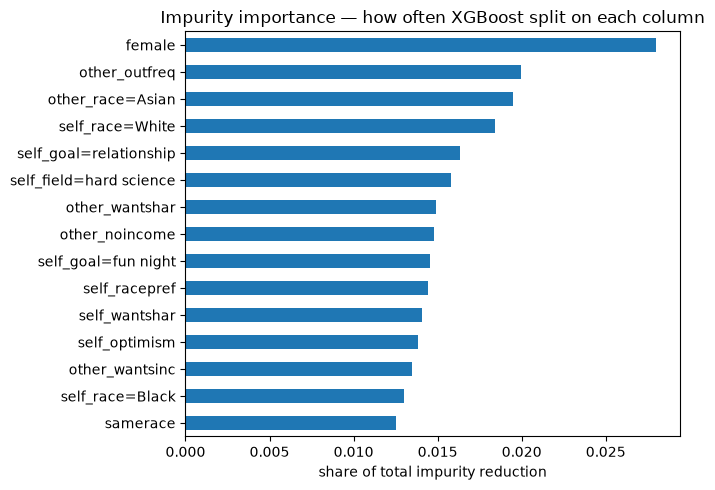

In [8]:
importance = pd.Series(final["xgboost"][-1].feature_importances_, index=COLUMNS)
importance = (importance / importance.sum()).nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot.barh(ax=ax)
ax.set_xlabel("share of total impurity reduction")
ax.set_title("Impurity importance — how often XGBoost split on each column")
plt.tight_layout()
plt.savefig("reports/figures/04_impurity_importance.png", dpi=150)
plt.show()

Partial dependence next: what the model predicts on average as one column moves, holding the others
at their observed values. The average is taken over the **marginal** distribution of the other
columns, so the curve includes combinations that never happen — a 20-year-old with the income of a
50-year-old. That is the standard objection to PDP and it applies here.

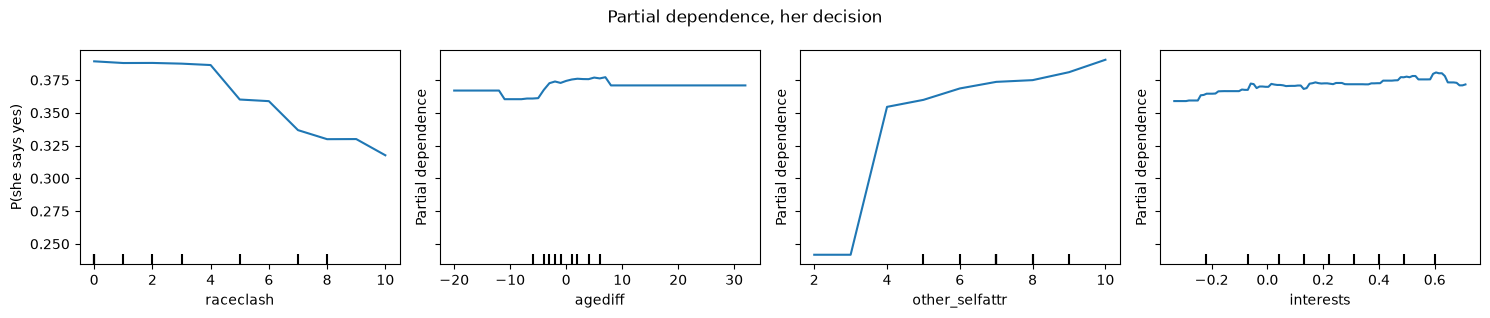

In [9]:
PDP_COLUMNS = ["raceclash", "agediff", "other_selfattr", "interests"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
PartialDependenceDisplay.from_estimator(final["xgboost"], hers, PDP_COLUMNS, ax=axes)
axes[0].set_ylabel("P(she says yes)")
fig.suptitle("Partial dependence, her decision")
plt.tight_layout()
plt.savefig("reports/figures/04_pdp.png", dpi=150)
plt.show()

A PDP is an average, and an average can hide two groups moving in opposite directions. Centred ICE
curves show one line per pair, all started at the same point, so a fan that opens means the effect
depends on who the person is.

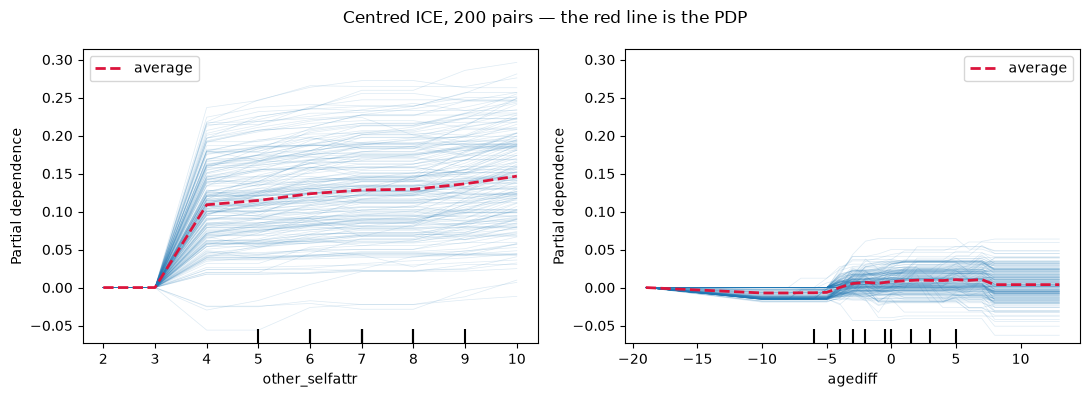

In [10]:
sample = hers.sample(200, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(final["xgboost"], sample, ["other_selfattr", "agediff"],
                                        kind="both", centered=True, ax=axes,
                                        ice_lines_kw={"alpha": 0.15, "linewidth": 0.5},
                                        pd_line_kw={"color": "crimson", "linewidth": 2})
fig.suptitle("Centred ICE, 200 pairs — the red line is the PDP")
plt.tight_layout()
plt.savefig("reports/figures/04_ice.png", dpi=150)
plt.show()

## 3. SHAP, one pair at a time

SHAP splits a single prediction into one contribution per column. Two things to get right here.

The additive scale is the **log-odds** of one decision, not the probability: XGBoost's raw output is
a margin, and `Σφ + φ₀ = margin` holds exactly. The pair score is p̂_her × p̂_his, additive in
log-probability, and log p = margin − log(1 + e^margin), which is monotone but not additive. So we
explain each stage on its own scale and read the two side by side, rather than adding them up.

efficiency check, worst pair: |sum of contributions + base - margin| = 2.86e-06


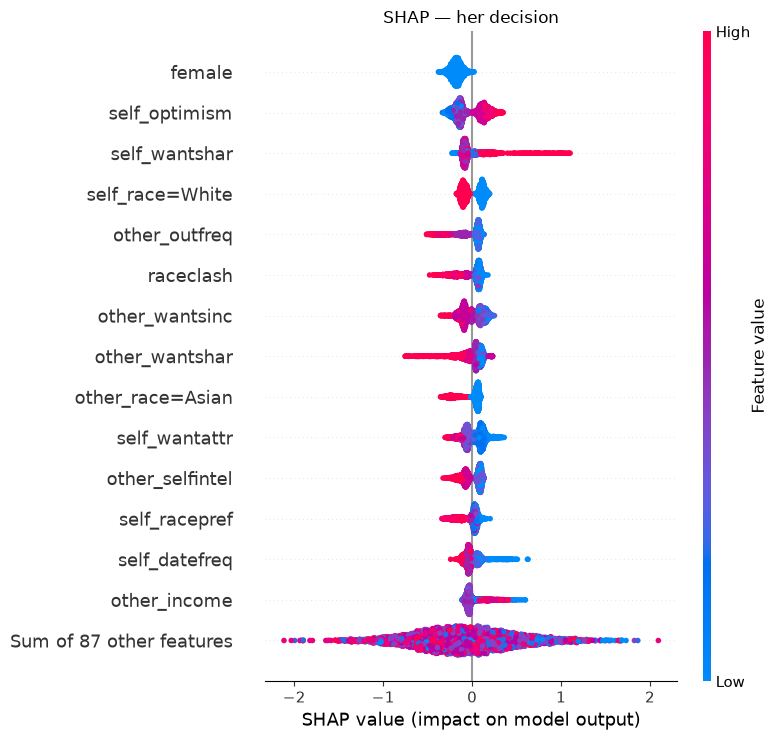

In [11]:
explainer = shap.TreeExplainer(final["xgboost"][-1])
shap_her = explainer(design(final["xgboost"], hers))
shap_his = explainer(design(final["xgboost"], his))

margin = final["xgboost"][-1].predict(design(final["xgboost"], hers).to_numpy(), output_margin=True)
residual = np.abs(shap_her.values.sum(1) + shap_her.base_values - margin).max()
print(f"efficiency check, worst pair: |sum of contributions + base - margin| = {residual:.2e}")

shap.plots.beeswarm(shap_her, max_display=15, show=False)
plt.title("SHAP — her decision")
plt.tight_layout()
plt.savefig("reports/figures/04_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

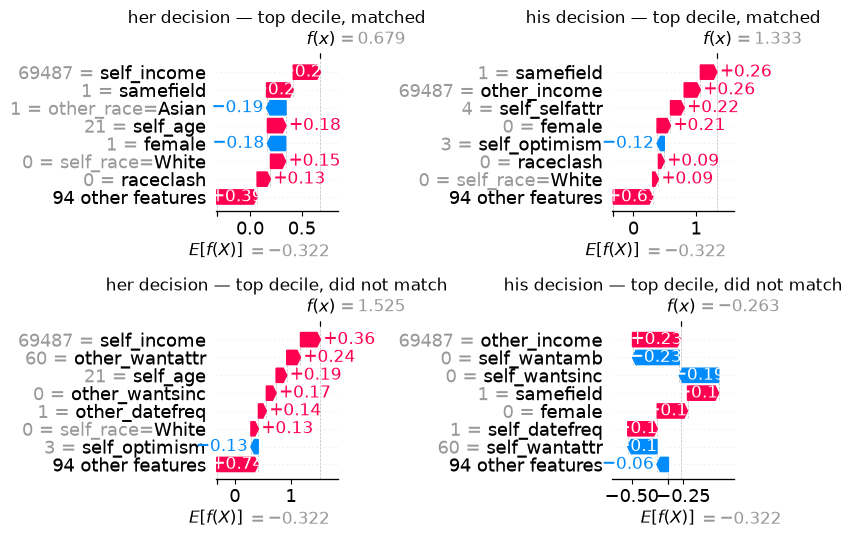

In [12]:
scores = pd.Series(out_of_fold("xgboost"), index=table.index)
shown = scores >= scores.quantile(0.9)
hit = table.index[shown & (table.match == 1)][0]
miss = table.index[shown & (table.match == 0)][0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (label, pair) in enumerate([("matched", hit), ("did not match", miss)]):
    for col, (stage, values) in enumerate([("her decision", shap_her), ("his decision", shap_his)]):
        plt.sca(axes[row, col])
        shap.plots.waterfall(values[pair], max_display=8, show=False)
        axes[row, col].set_title(f"{stage} — top decile, {label}")
plt.tight_layout()
plt.savefig("reports/figures/04_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Where the performance comes from

SHAP explains a prediction. It does not say whether a column earns its place: a model can lean hard
on a column that adds nothing. Two tools answer that question instead.

**Permutation importance** shuffles one column and measures how much the out-of-fold score drops.
Out-of-fold matters: shuffled in-sample, a column looks important simply because the model memorised
it. The column is shuffled in both stages at once, since it is the same variable on both sides.

In [13]:
RATES = {"PR-AUC": lambda s: average_precision_score(table.match, s),
         "top decile": lambda s: table.match[s >= np.quantile(s, 0.9)].mean()}

def permutation_importance(name, n_repeats=20, seed=SEED):
    rng = np.random.default_rng(seed)
    reference = {m: f(out_of_fold(name)) for m, f in RATES.items()}
    rows = []
    for column in hers.columns:
        drops = {m: [] for m in RATES}
        for _ in range(n_repeats):
            her_view, his_view = hers.copy(), his.copy()
            shuffled = rng.permutation(np.r_[her_view[column].to_numpy(), his_view[column].to_numpy()])
            her_view[column], his_view[column] = shuffled[:len(hers)], shuffled[len(hers):]
            score = out_of_fold(name, her_view, his_view)
            for m, f in RATES.items():
                drops[m].append(reference[m] - f(score))
        row = {"feature": column}
        for m in RATES:
            row[m] = np.mean(drops[m])
            row[f"{m} ± "] = 1.96 * np.std(drops[m]) / np.sqrt(n_repeats)
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")

permutation = permutation_importance("xgboost")
permutation.sort_values("top decile", ascending=False).head(12).round(4)

,PR-AUC,PR-AUC ±,top decile,top decile ±
feature,,,,
other_datefreq,0.0055,0.0007,0.0354,0.0030
raceclash,0.0072,0.0009,0.0320,0.0043
self_optimism,0.0036,0.0008,0.0311,0.0046
other_race,0.0075,0.0007,0.0307,0.0032
other_wantamb,0.0046,0.0005,0.0276,0.0025
female,0.0057,0.0014,0.0261,0.0045
other_wantattr,0.0027,0.0006,0.0260,0.0040
self_race,0.0036,0.0011,0.0242,0.0040
other_selffun,0.0016,0.0005,0.0226,0.0024


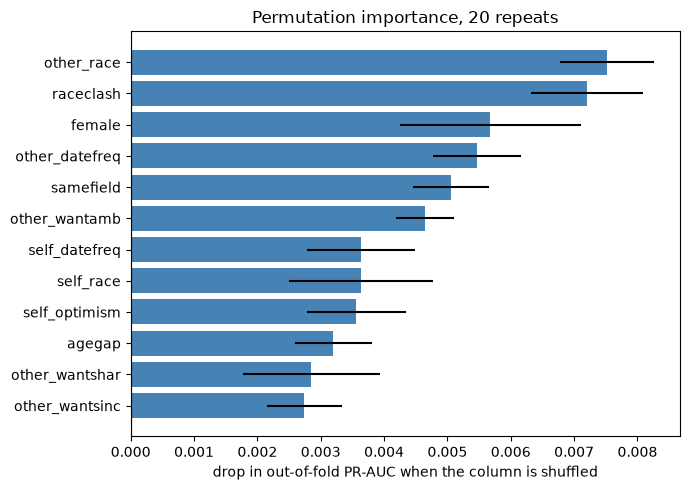

In [14]:
best = permutation.sort_values("PR-AUC", ascending=False).head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(best.index, best["PR-AUC"], xerr=best["PR-AUC ± "], color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("drop in out-of-fold PR-AUC when the column is shuffled")
ax.set_title("Permutation importance, 20 repeats")
plt.tight_layout()
plt.savefig("reports/figures/04_permutation_importance.png", dpi=150)
plt.show()
permutation.to_csv("reports/tables/04_permutation_importance.csv")

**XPER** goes one step further: it splits the performance measure itself, so that
PM = φ₀ + Σφⱼ, with φ₀ the AUC a model with no information would reach — 0.5. Each φⱼ is the share of
the model's skill that column brings.

Exact XPER needs 2^p coalitions and we have 101 encoded columns, which is out of reach. We run it on
a model refitted on the eight columns permutation importance ranks highest, in the package's
approximate mode. The decomposition therefore describes that reduced model, whose AUC is printed
below, not the full one. It takes about a minute.

Two things to read carefully. The approximation leaves a small gap between φ₀ + Σφⱼ and the measured
AUC, printed below — exact additivity is a property of the exact computation, not of this one. And a
contribution can be **negative**: the column costs the model performance rather than adding to it,
which is exactly the kind of thing impurity importance cannot tell you.

In [15]:
import contextlib, io

from XPER.compute.Performance import ModelPerformance

encoded = design(final["xgboost"], decisions)
ranked = permutation.sort_values("PR-AUC", ascending=False).index
top_eight = [c for c in ranked if c in encoded.columns][:8]   # the one-hot blocks cannot be split
train, test = (side_fold != 0).to_numpy(), (side_fold == 0).to_numpy()
reduced = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, eval_metric="logloss", random_state=0)
reduced.fit(encoded.loc[train, top_eight].to_numpy(), answers[train].to_numpy())

measure = ModelPerformance(encoded.loc[train, top_eight].to_numpy(), answers[train].to_numpy(),
                           encoded.loc[test, top_eight].to_numpy(), answers[test].to_numpy(),
                           reduced, sample_size=100, seed=SEED)
performance = measure.evaluate(["AUC"])
with contextlib.redirect_stderr(io.StringIO()):          # the progress bar floods the notebook
    phi, _ = measure.calculate_XPER_values(["AUC"], kernel=True, N_coalition_sampled=2**8 - 2)

xper = pd.Series(phi[1:], index=top_eight).sort_values()
measured = float(np.ravel(performance)[0])
print(f"AUC of the reduced model: {measured:.3f}")
print(f"benchmark phi_0: {phi[0]:.3f}   phi_0 + sum(phi_j): {phi[0] + sum(phi[1:]):.3f}   "
      f"gap left by the approximation: {abs(measured - phi[0] - sum(phi[1:])):.3f}")

AUC of the reduced model: 0.571
benchmark phi_0: 0.516   phi_0 + sum(phi_j): 0.558   gap left by the approximation: 0.013


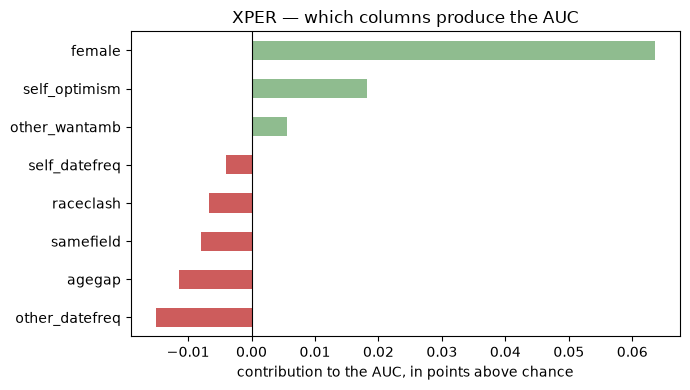

female            0.0636
self_optimism     0.0181
other_wantamb     0.0056
self_datefreq    -0.0041
raceclash        -0.0067
samefield        -0.0080
agegap           -0.0115
other_datefreq   -0.0151
dtype: float64

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
xper.plot.barh(ax=ax, color=np.where(xper > 0, "darkseagreen", "indianred"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("contribution to the AUC, in points above chance")
ax.set_title("XPER — which columns produce the AUC")
plt.tight_layout()
plt.savefig("reports/figures/04_xper.png", dpi=150)
plt.show()
xper.sort_values(ascending=False).round(4)

## 5. Do the four methods agree?

They measure different things — how often the tree split, how much a prediction moves, how much
performance is lost, how much skill is produced — so they are allowed to disagree. What matters is
knowing by how much before putting one of them on a slide.

In [17]:
shap_size = pd.Series(np.abs(shap_her.values).mean(0), index=COLUMNS)

def to_features(series):
    # Collapse the one-hot columns back onto the variable they came from, so the four are comparable.
    base = pd.Series({c: c.split("=")[0] for c in series.index})
    return series.abs().groupby(base).sum()

rankings = pd.DataFrame({
    "impurity": to_features(pd.Series(final["xgboost"][-1].feature_importances_, index=COLUMNS)),
    "permutation": permutation["PR-AUC"].abs(),
    "SHAP": to_features(shap_size),
    "XPER": to_features(xper)})

top5 = {m: set(rankings[m].nlargest(5).index) for m in rankings}
comparison = pd.DataFrame({m: rankings[m].nlargest(5).index.tolist() for m in rankings},
                          index=[f"#{i+1}" for i in range(5)])
agreement = pd.DataFrame({a: {b: len(top5[a] & top5[b]) / 5 for b in top5} for a in top5})
comparison

,impurity,permutation,SHAP,XPER
#1,self_field,other_race,female,female
#2,other_field,raceclash,self_optimism,self_optimism
#3,self_goal,self_income,self_race,other_datefreq
#4,other_race,female,other_race,agegap
#5,self_race,other_datefreq,self_wantshar,samefield


In [18]:
agreement.round(2)

,impurity,permutation,SHAP,XPER
impurity,1.0,0.2,0.4,0.0
permutation,0.2,1.0,0.4,0.4
SHAP,0.4,0.4,1.0,0.4
XPER,0.0,0.4,0.4,1.0


The four methods share **30% of their top five**, and two of them — impurity and XPER — share
nothing at all. That is the whole argument for not putting a single importance bar chart on a slide.

They disagree because they answer different questions. Impurity ranks the categorical blocks first,
`self_field` and `other_field`, simply because a column with eighteen categories offers more places
to split. Permutation and XPER, which both measure performance, put `female`, `self_optimism` and the
ethnicity columns on top. SHAP sits in between: it measures how much a prediction moves, which is
neither of the other two.

If one has to be chosen, it is XPER, because the client's question is "where does the skill come
from", not "where did the tree look".

## 6. Economic performance

No cost matrix yet, so we do not price a false positive. What we can do is compare the engine against
the only baseline the client actually has on day one: showing pairs at random.

In [19]:
base = oof.match.mean()
rows = []
for k in [0.05, 0.10, 0.20]:
    for name in ["logit", "xgboost", "logit_direct", "xgboost_direct"]:
        point, low, high = bootstrap_ci(oof, lambda d, n=name, q=k: top_k_rate(d, n, q), n_boot=500)
        rows.append({"shown": f"top {k:.0%}", "model": name, "match rate": round(point, 3),
                     "95% CI": f"[{low:.3f}, {high:.3f}]", "lift over random": round(point / base, 2),
                     "matches per 1,000 shown": int(round(1000 * point))})

economics = pd.DataFrame(rows).set_index(["shown", "model"])
economics.to_csv("reports/tables/04_economic_performance.csv")
economics

match rate          95% CI  lift over random  \
shown   model                                                          
top 5%  logit                0.314  [0.252, 0.375]              1.91   
        xgboost              0.290  [0.219, 0.341]              1.76   
        logit_direct         0.252  [0.198, 0.309]              1.53   
        xgboost_direct       0.233  [0.171, 0.288]              1.41   
top 10% logit                0.298  [0.249, 0.337]              1.81   
        xgboost              0.286  [0.236, 0.331]              1.74   
        logit_direct         0.236  [0.191, 0.272]              1.43   
        xgboost_direct       0.232  [0.188, 0.270]              1.40   
top 20% logit                0.235  [0.204, 0.264]              1.43   
        xgboost              0.234  [0.202, 0.261]              1.42   
        logit_direct         0.209  [0.182, 0.234]              1.27   
        xgboost_direct       0.219  [0.192, 0.246]              1.33   

                        matches per 1,000 shown  
shown   model                                    
top 5%  logit                               314  
        xgboost                             290  
        logit_direct                        252  
        xgboost_direct                      233  
top 10% logit                               298  
        xgboost                             286  
        logit_direct                        236  
        xgboost_direct                      232  
top 20% logit                               235  
        xgboost                             234  
        logit_direct                        209  
        xgboost_direct                      219

Random matching produces 165 matches per 1,000 pairs shown. The two-stage logit produces 299 in the
top decile, and holds 246 even when a fifth of the catalogue is shown, so the gain is not an artefact
of a very short list.

Two things this number does **not** prove, and the slide should say so.

**The snowball effect is an argument, not a measurement.** More good matches means more use, more use
means more data, more data means better matches. It is the right reason to invest in the engine, but
nobody in this dataset comes back a second time, so we cannot put a figure on it.

**A lift can be bought with exclusion.** A model that quietly stops recommending one group would also
raise the top-decile rate. Notebook 06 checks that this is not what happened, and the economic claim
is only valid if that check passes.

## 7. Does a simple tree say the same thing? (secondary)

A global surrogate: a depth-3 tree fitted on the **scores** of XGBoost, not on the target. If it
reproduces them well, the black box was simple all along. Fidelity is the R² of the tree on those
scores.

fidelity (R² on the black box scores): 0.242


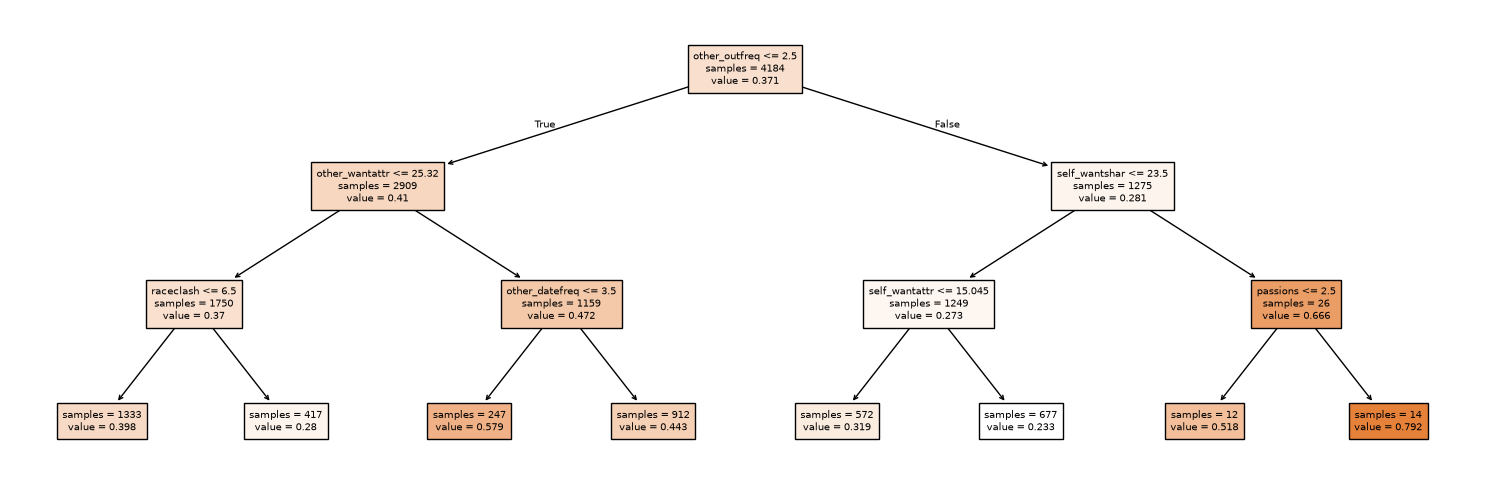

In [20]:
surrogate_x = design(final["xgboost"], hers)
surrogate_y = final["xgboost"].predict_proba(hers)[:, 1]
surrogate = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(surrogate_x, surrogate_y)
print(f"fidelity (R² on the black box scores): {r2_score(surrogate_y, surrogate.predict(surrogate_x)):.3f}")

fig, ax = plt.subplots(figsize=(15, 5))
plot_tree(surrogate, feature_names=COLUMNS, filled=True, fontsize=7, ax=ax, impurity=False)
plt.tight_layout()
plt.savefig("reports/figures/04_surrogate_tree.png", dpi=150)
plt.show()

In [21]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(surrogate_x.to_numpy(), feature_names=COLUMNS,
                                      class_names=["no", "yes"], discretize_continuous=True,
                                      random_state=SEED)
local = lime_explainer.explain_instance(surrogate_x.loc[hit].to_numpy(),
                                        lambda m: final["xgboost"][-1].predict_proba(m), num_features=6)
pd.DataFrame(local.as_list(), columns=["rule", "weight"]).round(3)

,rule,weight
0,self_race=Black <= 0.00,-0.068
1,other_race=Asian > 0.00,-0.057
2,self_optimism <= 4.00,-0.047
3,other_selfintel <= 8.00,0.035
4,self_race=White <= 0.00,0.034
5,other_selfamb <= 7.00,0.033


## What goes on the slide

In [22]:
print(f"white box keeps {len(kept)} of {len(COLUMNS)} columns")
print(f"strongest marginal effect: {coefficients.index[0]} at "
      f"{coefficients['Marginal Effect (%)'].iloc[0]:+.1f} points")
print(f"strongest continuous effect: {continuous.index[0]} at "
      f"{continuous['Marginal Effect (%)'].iloc[0]:+.1f} points per standard deviation")
print(f"top-decile match rate {top_k_rate(oof, 'logit'):.3f} against {base:.3f} at random "
      f"-> {top_k_rate(oof, 'logit') / base:.2f}x")
print(f"the four importance methods share {agreement.to_numpy()[np.triu_indices(4, 1)].mean():.0%} "
      f"of their top five")
print(f"surrogate tree fidelity {r2_score(surrogate_y, surrogate.predict(surrogate_x)):.2f}")

white box keeps 77 of 101 columns
strongest marginal effect: female at -13.7 points
strongest continuous effect: other_selfintel at -4.0 points per standard deviation
top-decile match rate 0.298 against 0.165 at random -> 1.81x
the four importance methods share 30% of their top five
surrogate tree fidelity 0.24
